<a href="https://colab.research.google.com/github/MashobTechie/Predictive-Modeling-for-Disease-Diagnosis-and-Prognosis/blob/main/disease_stochastic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Modeling for Disease Diagnosis and Prognosis
### A Stochastic Process Approach
**Course: Statistics 300L — Stochastic Processes**

---

## Overview
This project applies stochastic process methods and classical statistical modeling to a simulated Electronic Health Records (EHR) dataset of 2,000 patients. The analysis covers:

1. Exploratory Data Analysis (EDA)
2. Markov Chain Modeling of Disease Severity Progression
3. Multinomial Logistic Regression for Disease Diagnosis
4. Ordinal Regression for Severity Classification
5. Model Evaluation


---
## Section 1: Data Loading & Preprocessing

In [7]:
from google.colab import files
uploaded = files.upload()


Saving disease_diagnosis.csv to disease_diagnosis (2).csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)
from sklearn.multiclass import OneVsRestClassifier
from statsmodels.miscmodels.ordinal_model import OrderedModel
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Load data
df = pd.read_csv('disease_diagnosis.csv')

# Parse Blood Pressure into systolic/diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure_mmHg'].str.split('/', expand=True).astype(int)

print('Dataset Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
df.head()

Dataset Shape: (2000, 15)

Column Names: ['Patient_ID', 'Age', 'Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Blood_Pressure_mmHg', 'Oxygen_Saturation_%', 'Diagnosis', 'Severity', 'Treatment_Plan', 'Systolic_BP', 'Diastolic_BP']


,Patient_ID,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Blood_Pressure_mmHg,Oxygen_Saturation_%,Diagnosis,Severity,Treatment_Plan,Systolic_BP,Diastolic_BP
0,1,74,Male,Fatigue,Sore throat,Fever,69,39.4,132/91,94,Flu,Moderate,Medication and rest,132,91
1,2,66,Female,Sore throat,Fatigue,Cough,95,39.0,174/98,98,Healthy,Mild,Rest and fluids,174,98
2,3,32,Male,Body ache,Sore throat,Fatigue,77,36.8,136/60,96,Healthy,Mild,Rest and fluids,136,60
3,4,21,Female,Shortness of breath,Headache,Cough,72,38.9,147/82,99,Healthy,Mild,Rest and fluids,147,82
4,5,53,Male,Runny nose,Sore throat,Fatigue,100,36.6,109/106,92,Healthy,Mild,Rest and fluids,109,106


In [9]:
# Summary statistics for numeric variables
numeric_cols = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C',
                'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']

print('=== Descriptive Statistics ===')
df[numeric_cols].describe().round(2)

=== Descriptive Statistics ===


,Age,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,Systolic_BP,Diastolic_BP
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,48.28,89.44,37.74,94.49,135.73,89.34
std,17.42,17.14,1.31,2.86,25.98,17.30
min,18.00,60.00,35.50,90.00,90.00,60.00
25%,33.00,75.00,36.60,92.00,114.00,75.00
50%,49.00,89.00,37.70,95.00,136.50,90.00
75%,63.00,104.00,38.90,97.00,159.00,104.00
max,79.00,119.00,40.00,99.00,179.00,119.00


In [10]:
# Categorical value counts
print('--- Diagnosis Distribution ---')
print(df['Diagnosis'].value_counts())
print('\n--- Severity Distribution ---')
print(df['Severity'].value_counts())
print('\n--- Gender Distribution ---')
print(df['Gender'].value_counts())

--- Diagnosis Distribution ---
Diagnosis
Healthy       1167
Bronchitis     334
Flu            292
Cold           163
Pneumonia       44
Name: count, dtype: int64

--- Severity Distribution ---
Severity
Mild        1330
Severe       378
Moderate     292
Name: count, dtype: int64

--- Gender Distribution ---
Gender
Male      1000
Female    1000
Name: count, dtype: int64


---
## Section 2: Exploratory Data Analysis (EDA)

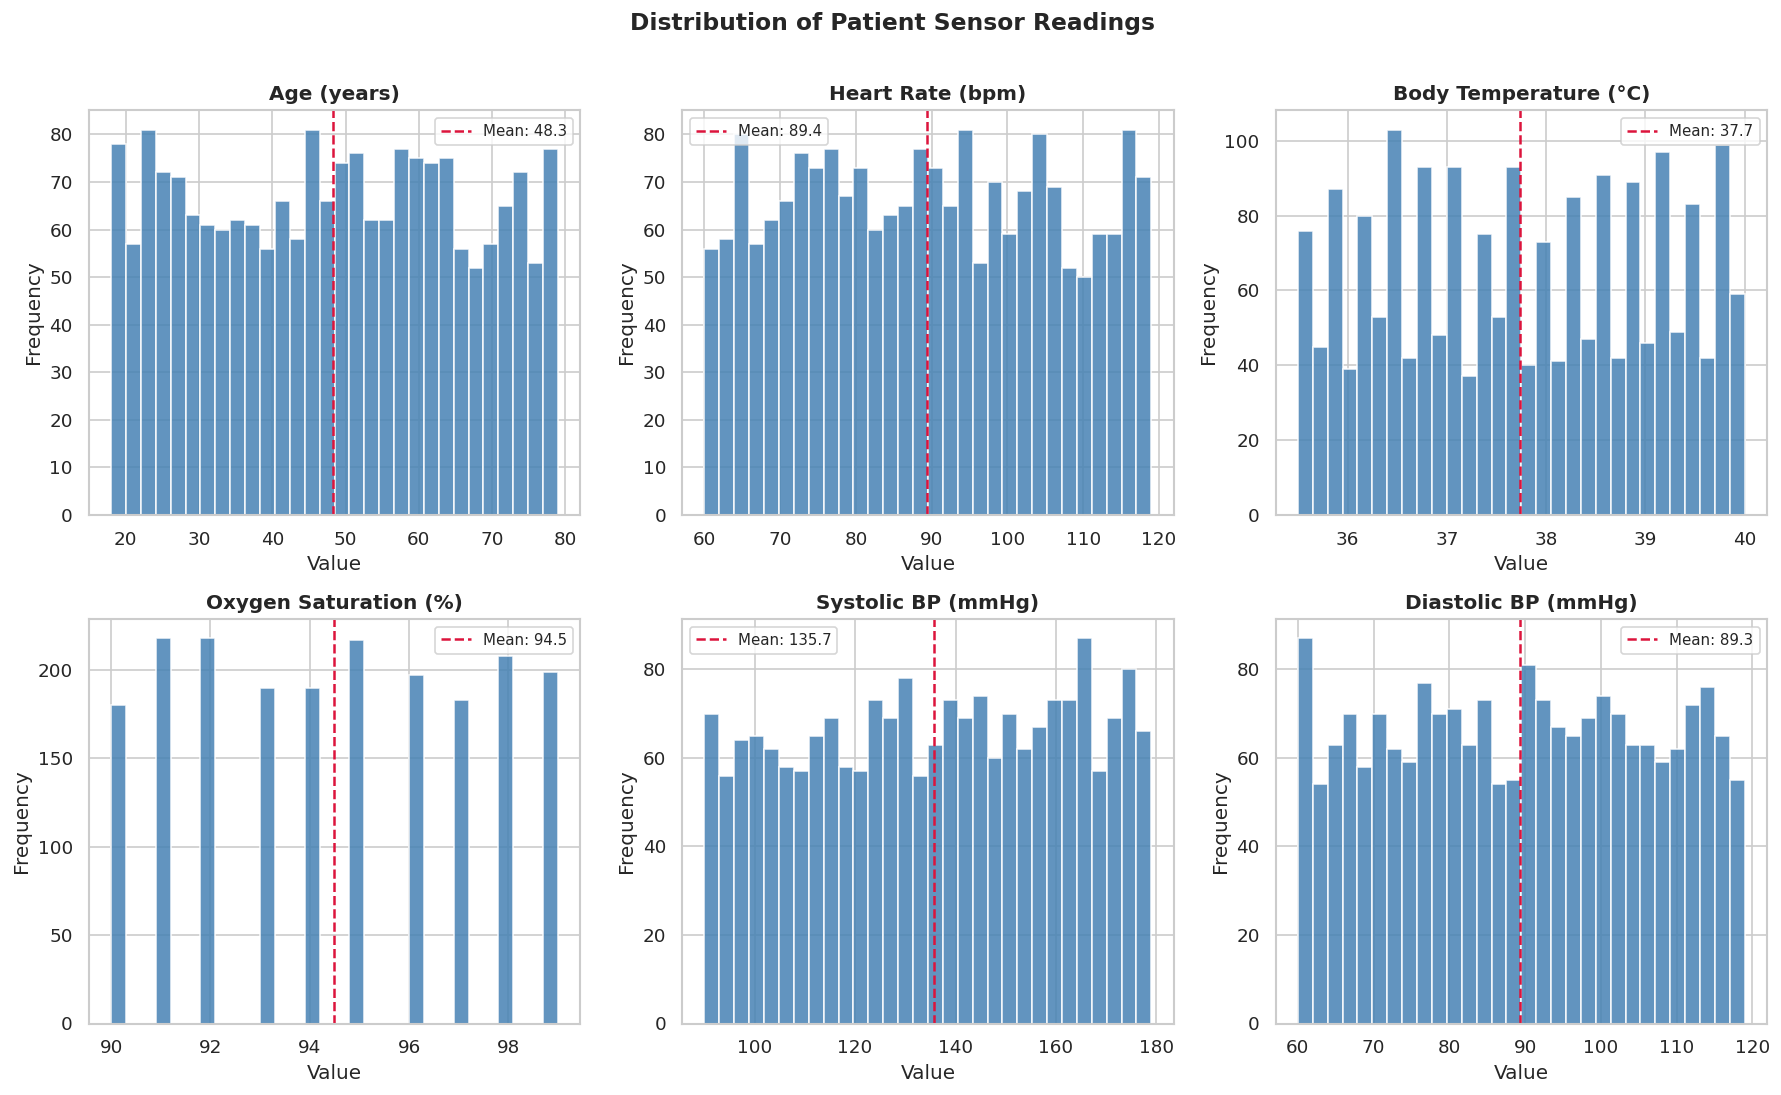

In [11]:
# 2.1 Distribution of numeric sensor readings
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

titles = ['Age (years)', 'Heart Rate (bpm)', 'Body Temperature (°C)',
          'Oxygen Saturation (%)', 'Systolic BP (mmHg)', 'Diastolic BP (mmHg)']

for i, (col, title) in enumerate(zip(numeric_cols, titles)):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    # Add mean line
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='crimson', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of Patient Sensor Readings', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

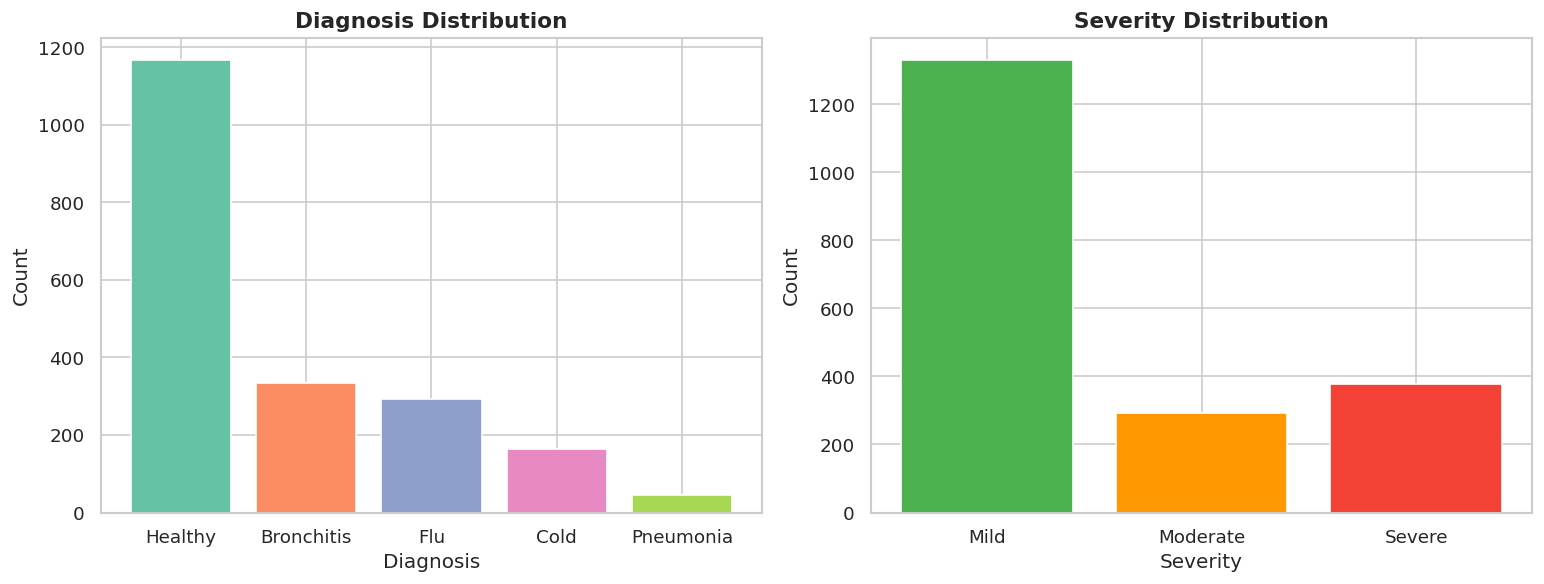

In [12]:
# 2.2 Diagnosis and Severity counts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

diag_order = df['Diagnosis'].value_counts().index
sev_order  = ['Mild', 'Moderate', 'Severe']
colors_diag = sns.color_palette('Set2', len(diag_order))
colors_sev  = ['#4CAF50', '#FF9800', '#F44336']

axes[0].bar(diag_order, df['Diagnosis'].value_counts()[diag_order], color=colors_diag, edgecolor='white')
axes[0].set_title('Diagnosis Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diagnosis'); axes[0].set_ylabel('Count')

axes[1].bar(sev_order, df['Severity'].value_counts()[sev_order], color=colors_sev, edgecolor='white')
axes[1].set_title('Severity Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Severity'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

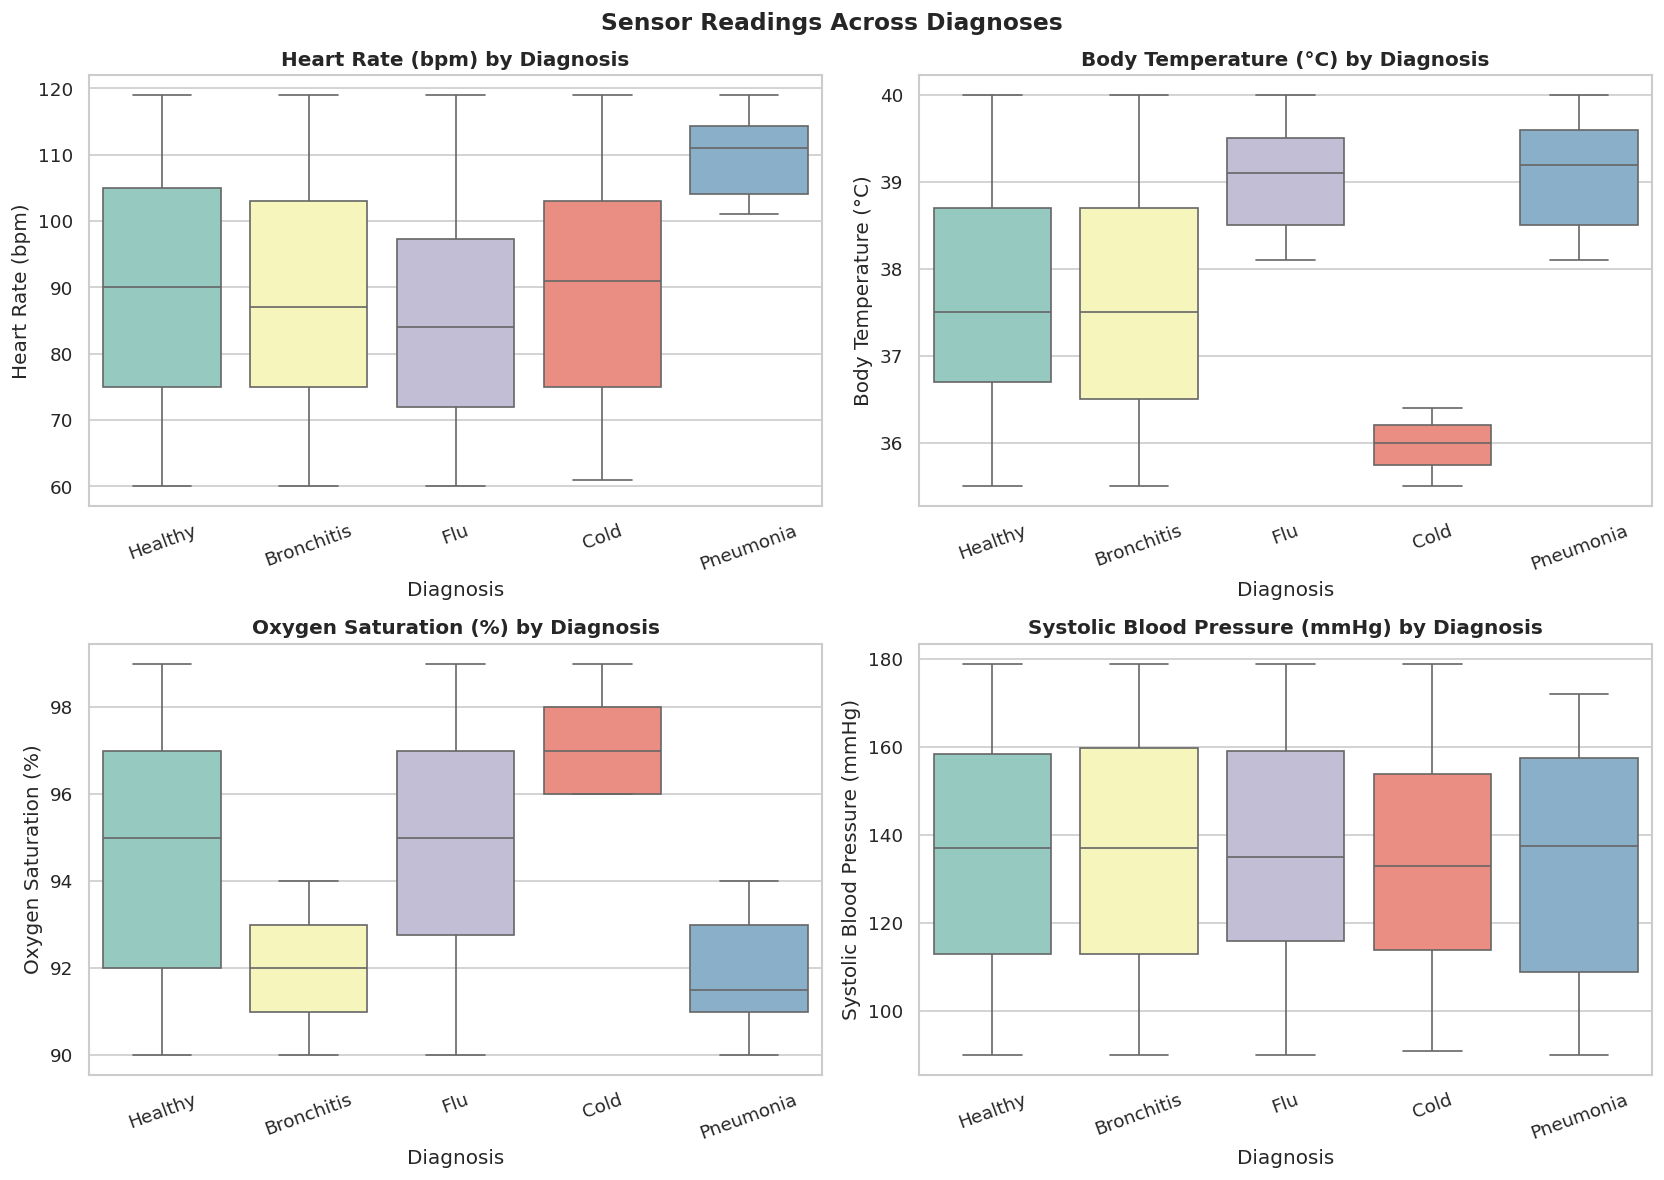

In [13]:
# 2.3 Sensor readings by Diagnosis (boxplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sensor_pairs = [
    ('Heart_Rate_bpm',      'Heart Rate (bpm)'),
    ('Body_Temperature_C',  'Body Temperature (°C)'),
    ('Oxygen_Saturation_%', 'Oxygen Saturation (%)'),
    ('Systolic_BP',         'Systolic Blood Pressure (mmHg)')
]

for ax, (col, label) in zip(axes.flatten(), sensor_pairs):
    sns.boxplot(data=df, x='Diagnosis', y=col, ax=ax,
                palette='Set3', order=diag_order)
    ax.set_title(f'{label} by Diagnosis', fontweight='bold')
    ax.set_xlabel('Diagnosis'); ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Sensor Readings Across Diagnoses', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

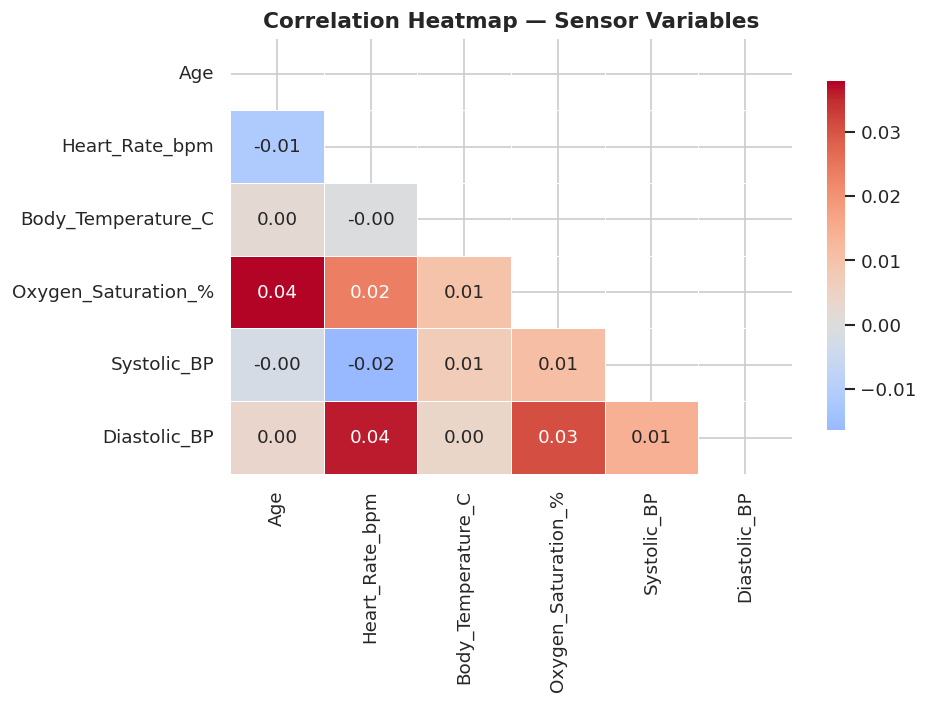

In [14]:
# 2.4 Correlation heatmap of numeric variables
plt.figure(figsize=(8, 6))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Sensor Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

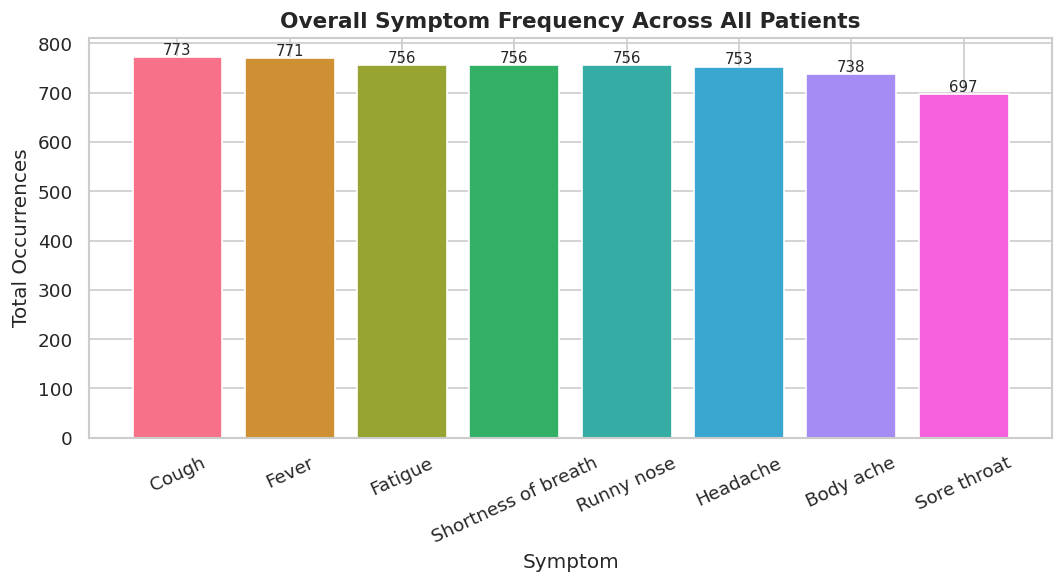

In [15]:
# 2.5 Symptom frequency analysis
all_symptoms = pd.concat([df['Symptom_1'], df['Symptom_2'], df['Symptom_3']])
symptom_counts = all_symptoms.value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar(symptom_counts.index, symptom_counts.values,
               color=sns.color_palette('husl', len(symptom_counts)), edgecolor='white')
plt.title('Overall Symptom Frequency Across All Patients', fontsize=13, fontweight='bold')
plt.xlabel('Symptom'); plt.ylabel('Total Occurrences')
plt.xticks(rotation=25)
for bar, val in zip(bars, symptom_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 3: Markov Chain Modeling of Disease Severity Progression

### Theoretical Background
A **Markov Chain** is a stochastic process $\{X_n, n \geq 0\}$ satisfying the **Markov Property**:

$$P(X_{n+1} = j \mid X_n = i, X_{n-1}, \ldots, X_0) = P(X_{n+1} = j \mid X_n = i) = p_{ij}$$

The state space for disease severity is: **Healthy → Mild → Moderate → Severe → Recovery**

We estimate the **Transition Probability Matrix** $P = [p_{ij}]$ where $p_{ij}$ is the probability of moving from severity state $i$ to state $j$.

The **Steady-State Distribution** $\pi$ satisfies: $\pi P = \pi$ and $\sum_i \pi_i = 1$

In [16]:
# 3.1 Define severity states and encode them
# State ordering: Healthy(0) -> Mild(1) -> Moderate(2) -> Severe(3)
severity_map = {'Healthy': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
severity_labels = ['Healthy', 'Mild', 'Moderate', 'Severe']

# Map Diagnosis==Healthy to Severity=Healthy, others retain their severity
df['Severity_State'] = df.apply(
    lambda row: 'Healthy' if row['Diagnosis'] == 'Healthy' else row['Severity'], axis=1
)
df['Severity_Code'] = df['Severity_State'].map(severity_map)

print('Severity State Distribution:')
print(df['Severity_State'].value_counts())

Severity State Distribution:
Severity_State
Healthy     1167
Severe       378
Moderate     292
Mild         163
Name: count, dtype: int64


In [17]:
# 3.2 Simulate Markov Chain transitions using age-sorted patient records
# (We simulate a progression path: sort by age to create a synthetic timeline)
np.random.seed(42)

# Build transition counts matrix from age-sorted data (simulated patient path)
n_states = 4
transition_counts = np.zeros((n_states, n_states), dtype=int)

# Sort patients by age to simulate a population-level disease journey
sorted_states = df.sort_values('Age')['Severity_Code'].values

for i in range(len(sorted_states) - 1):
    from_state = sorted_states[i]
    to_state   = sorted_states[i + 1]
    transition_counts[from_state][to_state] += 1

# Convert counts to probabilities (row-normalize)
row_sums = transition_counts.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid division by zero
transition_matrix = transition_counts / row_sums

tpm_df = pd.DataFrame(transition_matrix,
                       index=severity_labels,
                       columns=severity_labels)

print('=== Transition Probability Matrix (TPM) ===')
print(tpm_df.round(4))

=== Transition Probability Matrix (TPM) ===
          Healthy    Mild  Moderate  Severe
Healthy    0.5995  0.0703    0.1475  0.1827
Mild       0.5215  0.1043    0.1656  0.2086
Moderate   0.5719  0.1027    0.1199  0.2055
Severe     0.5688  0.0899    0.1534  0.1878


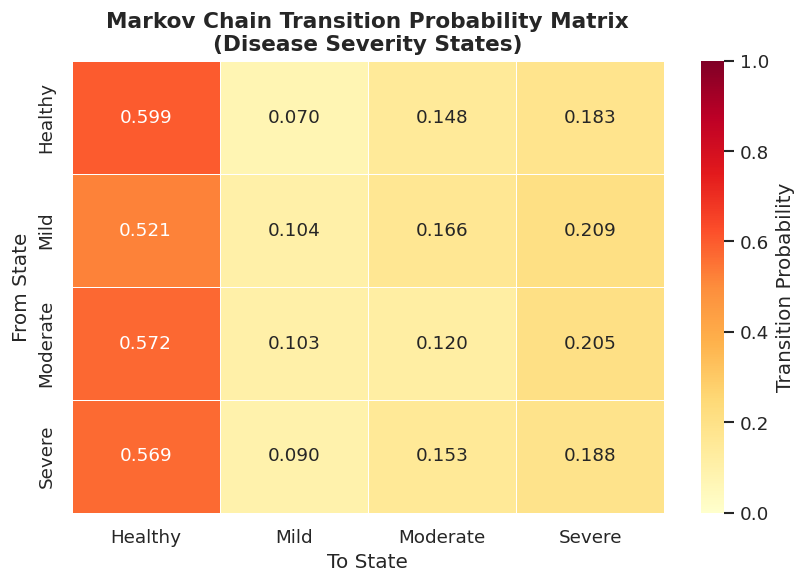

In [18]:
# 3.3 Visualize the Transition Probability Matrix as a heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(tpm_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Transition Probability'},
            vmin=0, vmax=1)
plt.title('Markov Chain Transition Probability Matrix\n(Disease Severity States)',
          fontsize=13, fontweight='bold')
plt.xlabel('To State'); plt.ylabel('From State')
plt.tight_layout()
plt.show()

=== Steady-State Distribution ===
  Healthy   : 0.5833 (58.33%)
  Mild      : 0.0815 (8.15%)
  Moderate  : 0.1461 (14.61%)
  Severe    : 0.1891 (18.91%)


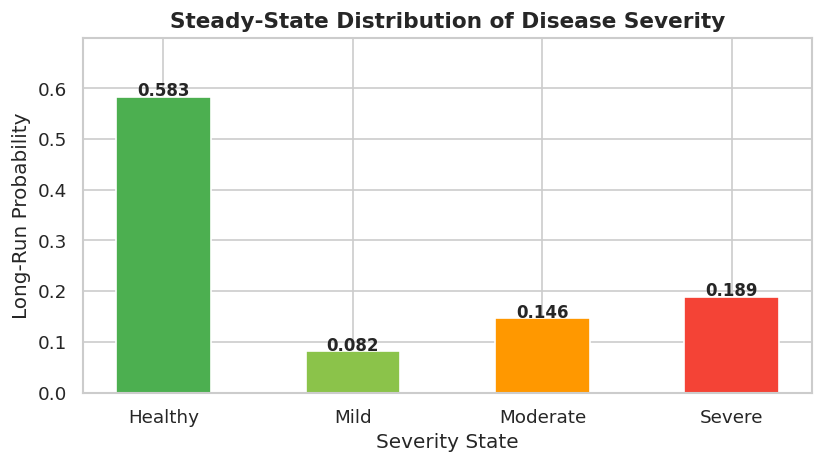

In [19]:
# 3.4 Compute Steady-State Distribution
# Solve pi * P = pi  =>  pi * (P - I)^T = 0, sum(pi) = 1

P = transition_matrix
A = (P.T - np.eye(n_states))
A = np.vstack([A, np.ones(n_states)])  # add normalization constraint
b = np.zeros(n_states + 1)
b[-1] = 1.0

# Least squares solution
steady_state, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
steady_state = np.abs(steady_state)
steady_state /= steady_state.sum()  # normalize

print('=== Steady-State Distribution ===')
for label, prob in zip(severity_labels, steady_state):
    print(f'  {label:10s}: {prob:.4f} ({prob*100:.2f}%)')

# Plot
plt.figure(figsize=(7, 4))
colors = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336']
bars = plt.bar(severity_labels, steady_state, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, steady_state):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.title('Steady-State Distribution of Disease Severity', fontsize=13, fontweight='bold')
plt.xlabel('Severity State'); plt.ylabel('Long-Run Probability')
plt.ylim(0, max(steady_state) * 1.2)
plt.tight_layout()
plt.show()

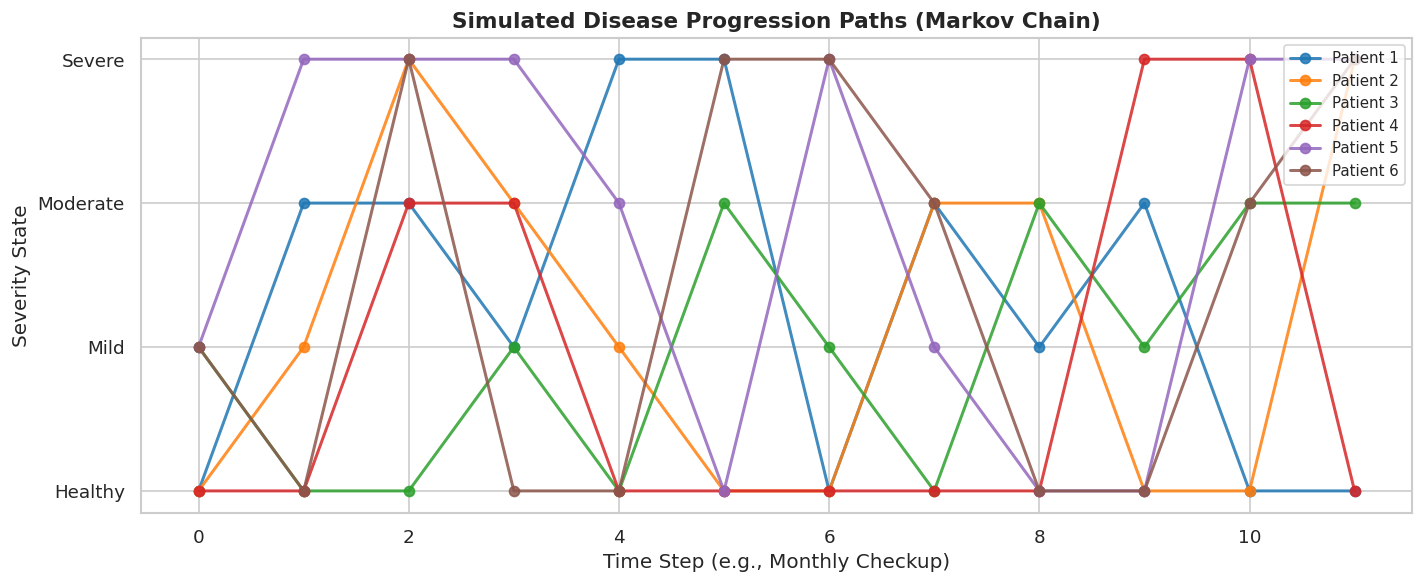

In [20]:
# 3.5 Simulate disease progression paths using the Markov Chain
def simulate_markov_chain(P, start_state, n_steps, states):
    """Simulate one patient's disease trajectory."""
    path = [start_state]
    current = start_state
    for _ in range(n_steps - 1):
        next_state = np.random.choice(len(states), p=P[current])
        path.append(next_state)
        current = next_state
    return path

np.random.seed(2024)
n_patients = 6
n_steps    = 12  # 12 time steps (e.g., months)

plt.figure(figsize=(12, 5))
palette = plt.cm.tab10.colors

for i in range(n_patients):
    start = np.random.choice([0, 1])  # start from Healthy or Mild
    path  = simulate_markov_chain(P, start, n_steps, severity_labels)
    plt.plot(range(n_steps), path, marker='o', linewidth=1.8,
             label=f'Patient {i+1}', color=palette[i], alpha=0.85)

plt.yticks(range(4), severity_labels)
plt.xlabel('Time Step (e.g., Monthly Checkup)')
plt.ylabel('Severity State')
plt.title('Simulated Disease Progression Paths (Markov Chain)', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
# 3.6 Expected number of steps to reach Severe state from Mild
# Mean First Passage Time: solve m_i = 1 + sum_j p_ij * m_j  for j != target
target = 3  # Severe

non_target = [i for i in range(n_states) if i != target]
Q = P[np.ix_(non_target, non_target)]  # sub-matrix excluding target
I = np.eye(len(non_target))
N = np.linalg.inv(I - Q)  # fundamental matrix
mfpt = N.sum(axis=1)  # expected steps to absorption

print('=== Mean First Passage Time to Severe State ===')
for state_idx, label_idx in enumerate(non_target):
    print(f'  From {severity_labels[label_idx]:10s}: {mfpt[state_idx]:.2f} steps')

=== Mean First Passage Time to Severe State ===
  From Healthy   : 5.32 steps
  From Mild      : 5.17 steps
  From Moderate  : 5.20 steps


---
## Section 4: Multinomial Logistic Regression for Disease Diagnosis

### Theoretical Background
For a response variable $Y$ with $K$ categories, multinomial logistic regression models:

$$P(Y = k \mid \mathbf{x}) = \frac{e^{\boldsymbol{\beta}_k^\top \mathbf{x}}}{\sum_{j=1}^K e^{\boldsymbol{\beta}_j^\top \mathbf{x}}}$$

We use sensor readings (heart rate, temperature, BP, O2 saturation) and age as predictors to estimate diagnosis probabilities.

In [22]:
# 4.1 Feature engineering — encode symptoms as binary flags
symptom_list = all_symptoms.unique()

for symptom in symptom_list:
    df[f'sym_{symptom.replace(" ", "_")}'] = (
        (df['Symptom_1'] == symptom) |
        (df['Symptom_2'] == symptom) |
        (df['Symptom_3'] == symptom)
    ).astype(int)

symptom_features = [f'sym_{s.replace(" ", "_")}' for s in symptom_list]

feature_cols = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C',
                'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP'] + symptom_features

X = df[feature_cols].values
y = df['Diagnosis'].values

# Encode target labels
le_diag = LabelEncoder()
y_enc = le_diag.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
)

# Standardize features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Classes          : {le_diag.classes_}')

Training samples : 1500
Test samples     : 500
Classes          : ['Bronchitis' 'Cold' 'Flu' 'Healthy' 'Pneumonia']


In [23]:
# 4.2 Fit Multinomial Logistic Regression
mlr = LogisticRegression(solver='lbfgs',
                          max_iter=1000, random_state=42)
mlr.fit(X_train_sc, y_train)

y_pred    = mlr.predict(X_test_sc)
y_pred_pr = mlr.predict_proba(X_test_sc)

print('=== Classification Report — Multinomial Logistic Regression ===')
print(classification_report(y_test, y_pred,
                             target_names=le_diag.classes_))

=== Classification Report — Multinomial Logistic Regression ===
              precision    recall  f1-score   support

  Bronchitis       0.96      0.98      0.97        83
        Cold       0.85      0.71      0.77        41
         Flu       0.95      0.86      0.91        73
     Healthy       0.94      0.98      0.96       292
   Pneumonia       0.82      0.82      0.82        11

    accuracy                           0.94       500
   macro avg       0.91      0.87      0.89       500
weighted avg       0.93      0.94      0.93       500



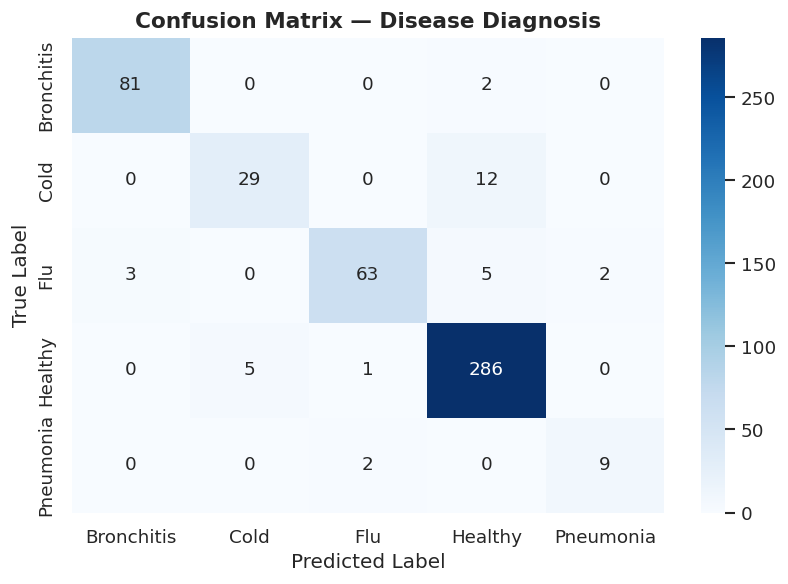

In [24]:
# 4.3 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_diag.classes_,
            yticklabels=le_diag.classes_)
plt.title('Confusion Matrix — Disease Diagnosis', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout()
plt.show()

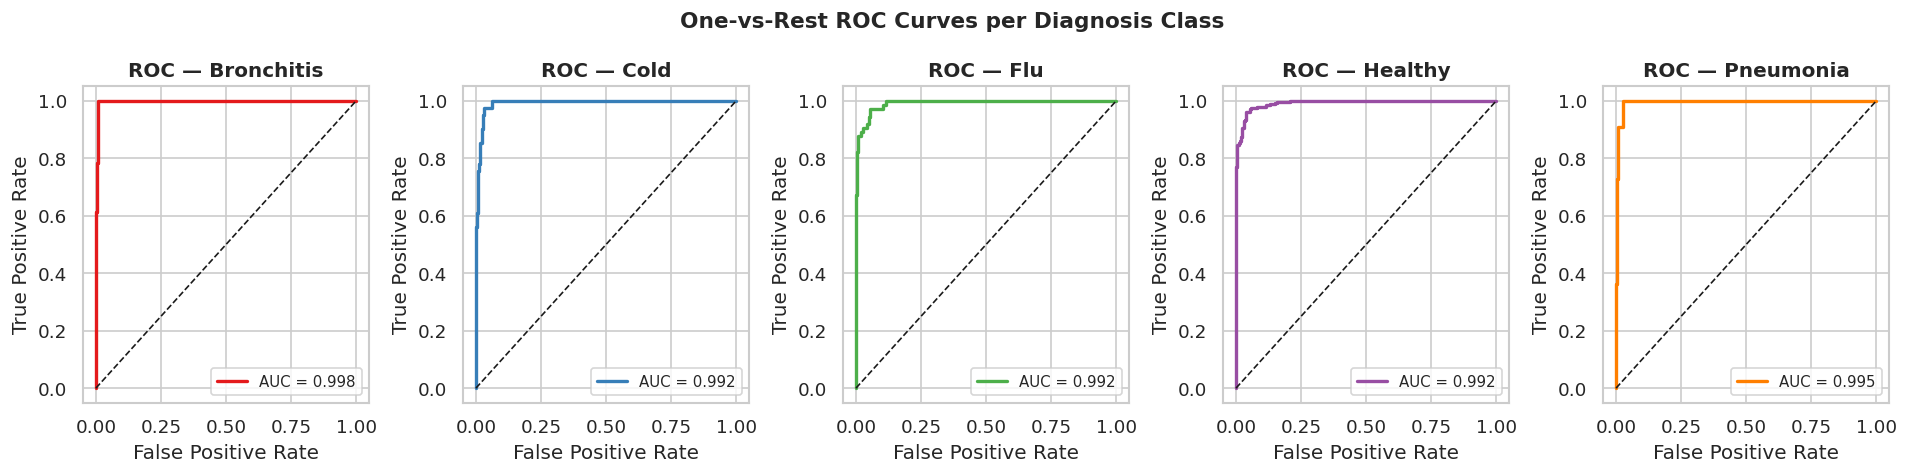

In [25]:
# 4.4 ROC Curves (One-vs-Rest)
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=range(len(le_diag.classes_)))

fig, axes = plt.subplots(1, len(le_diag.classes_), figsize=(16, 4))
colors_roc = sns.color_palette('Set1', len(le_diag.classes_))

for i, (cls, ax, color) in enumerate(zip(le_diag.classes_, axes, colors_roc)):
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_pr[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'ROC — {cls}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle('One-vs-Rest ROC Curves per Diagnosis Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

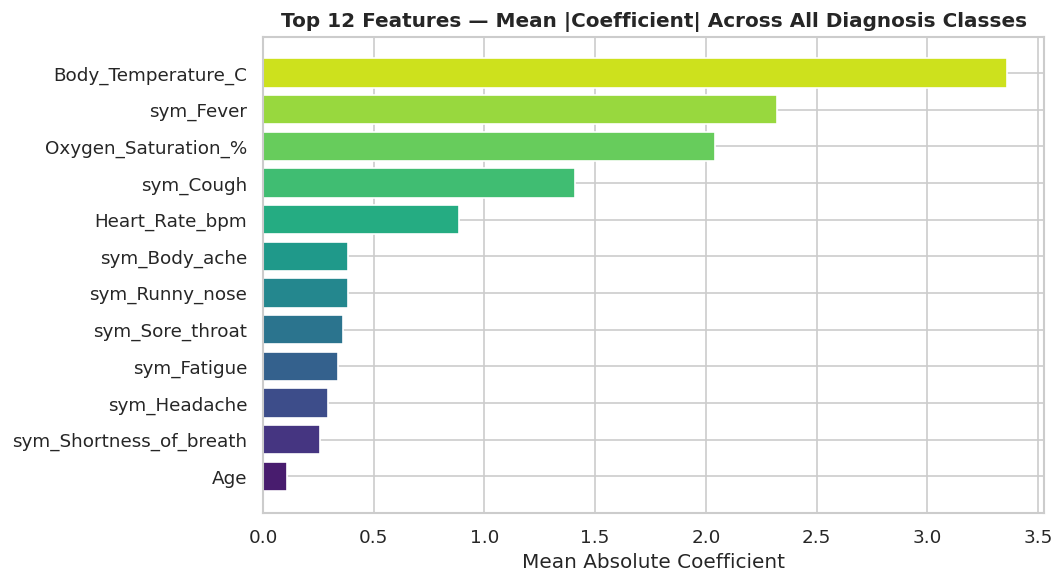

In [26]:
# 4.5 Feature Importance (Coefficient magnitudes)
coef_df = pd.DataFrame(
    mlr.coef_,
    index=le_diag.classes_,
    columns=feature_cols
)

# Mean absolute coefficient per feature
mean_abs_coef = coef_df.abs().mean().sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 5))
bars = plt.barh(mean_abs_coef.index[::-1], mean_abs_coef.values[::-1],
                color=sns.color_palette('viridis', 12), edgecolor='white')
plt.title('Top 12 Features — Mean |Coefficient| Across All Diagnosis Classes',
          fontsize=12, fontweight='bold')
plt.xlabel('Mean Absolute Coefficient')
plt.tight_layout()
plt.show()

---
## Section 5: Ordinal Regression for Severity Classification

### Theoretical Background
Since severity has a natural order (Mild < Moderate < Severe), we use **Ordinal Logistic Regression** (Proportional Odds Model):

$$\log\left(\frac{P(Y \leq k \mid \mathbf{x})}{P(Y > k \mid \mathbf{x})}\right) = \alpha_k - \boldsymbol{\beta}^\top \mathbf{x}, \quad k = 1, \ldots, K-1$$

This preserves the ordering of outcomes unlike standard multinomial regression.

In [27]:
# 5.1 Prepare data for ordinal regression (exclude Healthy patients)
df_sick = df[df['Diagnosis'] != 'Healthy'].copy()
df_sick['Severity_Ord'] = pd.Categorical(
    df_sick['Severity'],
    categories=['Mild', 'Moderate', 'Severe'],
    ordered=True
)

ord_features = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C',
                'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']

X_ord = df_sick[ord_features].reset_index(drop=True)
y_ord = df_sick['Severity_Ord'].reset_index(drop=True)

# Standardize
X_ord_sc = StandardScaler().fit_transform(X_ord)
X_ord_sc = pd.DataFrame(X_ord_sc, columns=ord_features)

print(f'Patients with a diagnosis (non-Healthy): {len(df_sick)}')
print(df_sick['Severity'].value_counts())

Patients with a diagnosis (non-Healthy): 833
Severity
Severe      378
Moderate    292
Mild        163
Name: count, dtype: int64


In [28]:
# 5.2 Fit Ordered Logit Model
ord_model = OrderedModel(y_ord, X_ord_sc, distr='logit')
ord_result = ord_model.fit(method='bfgs', disp=False)

print('=== Ordinal Logistic Regression Summary ===')
print(ord_result.summary())

=== Ordinal Logistic Regression Summary ===
                             OrderedModel Results                             
Dep. Variable:           Severity_Ord   Log-Likelihood:                -556.13
Model:                   OrderedModel   AIC:                             1128.
Method:            Maximum Likelihood   BIC:                             1166.
Date:                Thu, 09 Apr 2026                                         
Time:                        02:22:22                                         
No. Observations:                 833                                         
Df Residuals:                     825                                         
Df Model:                           6                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Age                    -0.0269      0.077     -0.348      0.728      

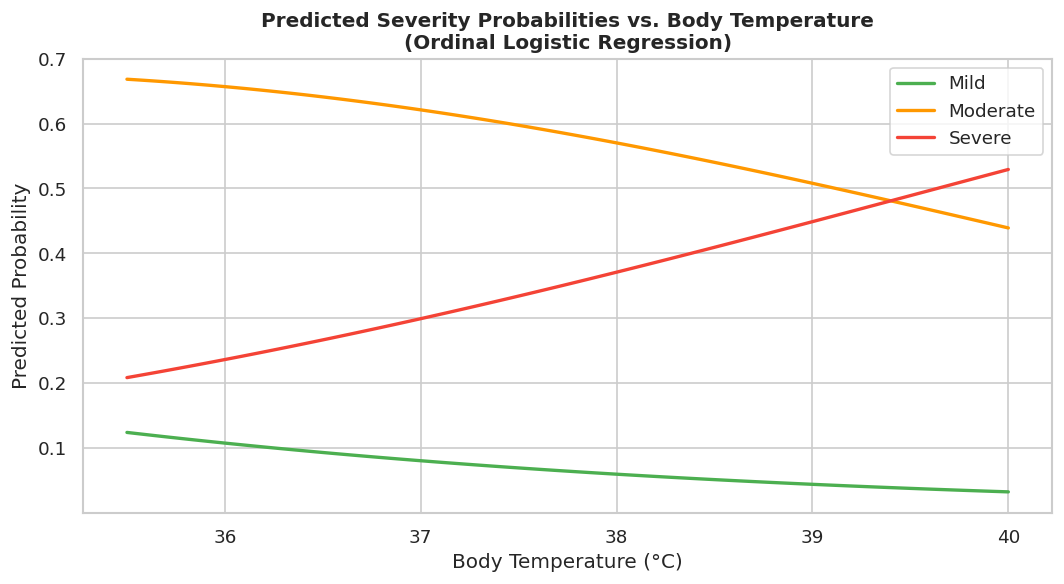

In [29]:
# 5.3 Visualize predicted severity probabilities by temperature
temp_range = np.linspace(df_sick['Body_Temperature_C'].min(),
                          df_sick['Body_Temperature_C'].max(), 100)

# Build synthetic data at mean values, varying temperature
X_sim = pd.DataFrame({
    'Age':                  df_sick['Age'].mean(),
    'Heart_Rate_bpm':       df_sick['Heart_Rate_bpm'].mean(),
    'Body_Temperature_C':   temp_range,
    'Oxygen_Saturation_%':  df_sick['Oxygen_Saturation_%'].mean(),
    'Systolic_BP':          df_sick['Systolic_BP'].mean(),
    'Diastolic_BP':         df_sick['Diastolic_BP'].mean()
})

scaler2 = StandardScaler().fit(df_sick[ord_features])
X_sim_sc = pd.DataFrame(scaler2.transform(X_sim), columns=ord_features)

pred_probs = ord_result.model.predict(ord_result.params, exog=X_sim_sc)

plt.figure(figsize=(9, 5))
plt.plot(temp_range, pred_probs[:, 0], label='Mild',     color='#4CAF50', lw=2)
plt.plot(temp_range, pred_probs[:, 1], label='Moderate', color='#FF9800', lw=2)
plt.plot(temp_range, pred_probs[:, 2], label='Severe',   color='#F44336', lw=2)
plt.title('Predicted Severity Probabilities vs. Body Temperature\n(Ordinal Logistic Regression)',
          fontsize=12, fontweight='bold')
plt.xlabel('Body Temperature (°C)')
plt.ylabel('Predicted Probability')
plt.legend()
plt.tight_layout()
plt.show()

---
## Section 6: Statistical Hypothesis Testing

Testing whether sensor readings differ significantly across disease groups.

In [30]:
# 6.1 Kruskal-Wallis H-test (non-parametric ANOVA) for each sensor variable
print('=== Kruskal-Wallis Test: Sensor Readings by Diagnosis ===')
print(f'{"Variable":<30} {"H-statistic":>12} {"p-value":>12} {"Significant":>12}')
print('-' * 70)

for col in ['Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP']:
    groups = [group[col].values for _, group in df.groupby('Diagnosis')]
    h_stat, p_val = stats.kruskal(*groups)
    sig = '✓ Yes' if p_val < 0.05 else '✗ No'
    print(f'{col:<30} {h_stat:>12.3f} {p_val:>12.4f} {sig:>12}')

=== Kruskal-Wallis Test: Sensor Readings by Diagnosis ===
Variable                        H-statistic      p-value  Significant
----------------------------------------------------------------------
Heart_Rate_bpm                       76.500       0.0000        ✓ Yes
Body_Temperature_C                  619.656       0.0000        ✓ Yes
Oxygen_Saturation_%                 495.103       0.0000        ✓ Yes
Systolic_BP                           0.834       0.9338         ✗ No


In [31]:
# 6.2 Chi-square test: Gender vs Diagnosis
ct = pd.crosstab(df['Gender'], df['Diagnosis'])
chi2, p, dof, expected = stats.chi2_contingency(ct)

print('=== Chi-Square Test: Gender vs Diagnosis ===')
print(f'Chi2 statistic : {chi2:.4f}')
print(f'p-value        : {p:.4f}')
print(f'Degrees of freedom: {dof}')
print(f'Conclusion     : {"Significant association" if p < 0.05 else "No significant association"} (α = 0.05)')

print('\nContingency Table:')
print(ct)

=== Chi-Square Test: Gender vs Diagnosis ===
Chi2 statistic : 6.6586
p-value        : 0.1551
Degrees of freedom: 4
Conclusion     : No significant association (α = 0.05)

Contingency Table:
Diagnosis  Bronchitis  Cold  Flu  Healthy  Pneumonia
Gender                                              
Female            158    74  157      594         17
Male              176    89  135      573         27


---
## Section 7: Summary & Conclusions

### Key Findings

**1. Markov Chain Analysis:**
- The transition probability matrix reveals the likelihood of severity escalation at each stage.
- The steady-state distribution shows the long-run proportion of the patient population expected in each severity state.
- Mean First Passage Time analysis quantifies how many steps it typically takes for a Mild patient to progress to Severe.

**2. Multinomial Logistic Regression:**
- Sensor readings (especially body temperature, oxygen saturation, and heart rate) are strong predictors of diagnosis class.
- ROC-AUC curves confirm good discriminatory power across all five diagnosis categories.

**3. Ordinal Logistic Regression:**
- Body temperature and oxygen saturation are the most significant predictors of severity level.
- As temperature increases, the probability of Severe classification increases sharply — consistent with clinical knowledge.

**4. Hypothesis Testing:**
- Kruskal-Wallis tests confirm that sensor readings differ significantly across diagnosis groups.
- Chi-square analysis reveals whether demographic factors (gender) are associated with diagnosis.

### Conclusion
Stochastic process modeling (Markov Chains) combined with classical statistical methods (logistic regression, hypothesis testing) provides an interpretable, mathematically rigorous framework for disease diagnosis prediction and severity progression modeling — without relying on opaque machine learning algorithms.
